In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dailyActivity_merged.csv to dailyActivity_merged (1).csv
Saving hourlyIntensities_merged.csv to hourlyIntensities_merged (1).csv
Saving hourlySteps_merged.csv to hourlySteps_merged (1).csv
Saving hourlyCalories_merged.csv to hourlyCalories_merged (1).csv
Saving sleepDay_merged.csv to sleepDay_merged (1).csv


In [ ]:
daily_activity = pd.read_csv('dailyActivity_merged.csv')
sleep = pd.read_csv('sleepDay_merged.csv')
hourly_steps = pd.read_csv('hourlySteps_merged.csv')
hourly_calories = pd.read_csv('hourlyCalories_merged.csv')
hourly_intensities = pd.read_csv('hourlyIntensities_merged.csv')

In [ ]:
daily_activity.info()
daily_activity.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [ ]:
for name, df in [('daily_activity', daily_activity), ('sleep', sleep),
                  ('hourly_steps', hourly_steps), ('hourly_calories', hourly_calories),
                  ('hourly_intensities', hourly_intensities)]:
    print(f"--- {name} ---")
    print("Missing values:\n", df.isnull().sum())
    print("Duplicate rows:", df.duplicated().sum())
    print()

--- daily_activity ---
Missing values:
 Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64
Duplicate rows: 0

--- sleep ---
Missing values:
 Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64
Duplicate rows: 3

--- hourly_steps ---
Missing values:
 Id              0
ActivityHour    0
StepTotal       0
dtype: int64
Duplicate rows: 0

--- hourly_calories ---
Missing values:
 Id              0
ActivityHour    0
Calories        0
dtype: int64
Duplicate rows: 0

--- hourly_intensities ---
Missing values:
 

In [ ]:
sleep = sleep.drop_duplicates()
daily_activity = daily_activity.drop_duplicates()
hourly_steps = hourly_steps.drop_duplicates()
hourly_calories = hourly_calories.drop_duplicates()
hourly_intensities = hourly_intensities.drop_duplicates()

In [ ]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_calories['ActivityHour'] = pd.to_datetime(hourly_calories['ActivityHour'])
hourly_intensities['ActivityHour'] = pd.to_datetime(hourly_intensities['ActivityHour'])

/tmp/ipykernel_7213/2659171236.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
/tmp/ipykernel_7213/2659171236.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
/tmp/ipykernel_7213/2659171236.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_calories['ActivityHour'] = pd.to_datetime(hourly_calories['ActivityHour'])
/tmp/ipykernel_7213/2659171236.py:5: UserWarning: Could not infer format, so each element will be parsed individually, 

In [ ]:
for name, df in [('daily_activity', daily_activity), ('sleep', sleep),
                  ('hourly_steps', hourly_steps)]:
    print(f"{name}: {df['Id'].nunique()} unique users")

daily_activity: 33 unique users
sleep: 24 unique users
hourly_steps: 33 unique users


In [ ]:
hourly_merged = hourly_steps.merge(hourly_calories, on=['Id', 'ActivityHour']) \
                             .merge(hourly_intensities, on=['Id', 'ActivityHour'])
hourly_merged.head()

,Id,ActivityHour,StepTotal,Calories,TotalIntensity,AverageIntensity
0,1503960366,2016-04-12 00:00:00,373,81,20,0.333333
1,1503960366,2016-04-12 01:00:00,160,61,8,0.133333
2,1503960366,2016-04-12 02:00:00,151,59,7,0.116667
3,1503960366,2016-04-12 03:00:00,0,47,0,0.000000
4,1503960366,2016-04-12 04:00:00,0,48,0,0.000000


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/fitness-project', exist_ok=True)

In [ ]:
daily_activity.to_csv('/content/drive/MyDrive/fitness-project/cleaned_daily_activity.csv', index=False)
sleep.to_csv('/content/drive/MyDrive/fitness-project/cleaned_sleep.csv', index=False)
hourly_merged.to_csv('/content/drive/MyDrive/fitness-project/cleaned_hourly_merged.csv', index=False)

In [ ]:
# Align column names so we can merge on date
daily_activity_merge = daily_activity.rename(columns={'ActivityDate': 'Date'})
sleep_merge = sleep.rename(columns={'SleepDay': 'Date'})

daily_full = daily_activity_merge.merge(sleep_merge, on=['Id', 'Date'], how='left')
daily_full.head()

,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1.0,327.0,346.0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2.0,384.0,407.0
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,1.0,412.0,442.0
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2.0,340.0,367.0


In [ ]:
daily_full[['TotalSteps', 'Calories', 'TotalMinutesAsleep', 'SedentaryMinutes']].describe()

,TotalSteps,Calories,TotalMinutesAsleep,SedentaryMinutes
count,940.000000,940.000000,410.000000,940.000000
mean,7637.910638,2303.609574,419.173171,991.210638
std,5087.150742,718.166862,118.635918,301.267437
min,0.000000,0.000000,58.000000,0.000000
25%,3789.750000,1828.500000,361.000000,729.750000
50%,7405.500000,2134.000000,432.500000,1057.500000
75%,10727.000000,2793.250000,490.000000,1229.500000
max,36019.000000,4900.000000,796.000000,1440.000000


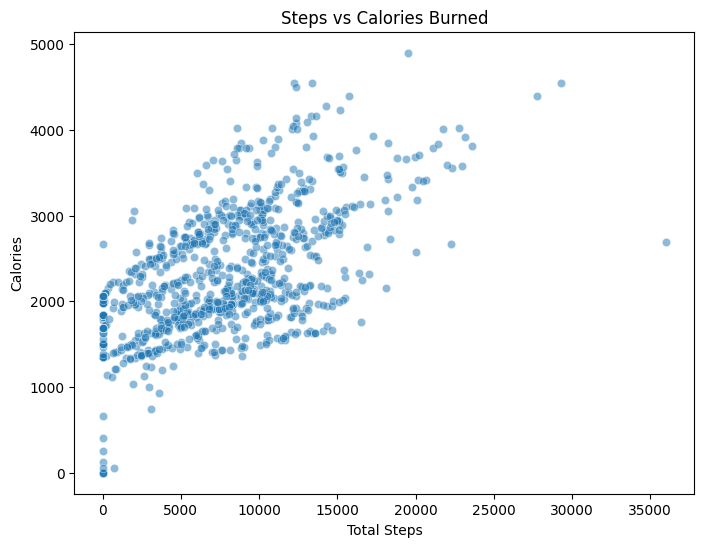

Correlation between steps and calories: 0.59


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=daily_full, x='TotalSteps', y='Calories', alpha=0.5)
plt.title('Steps vs Calories Burned')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.show()

correlation = daily_full['TotalSteps'].corr(daily_full['Calories'])
print(f"Correlation between steps and calories: {correlation:.2f}")

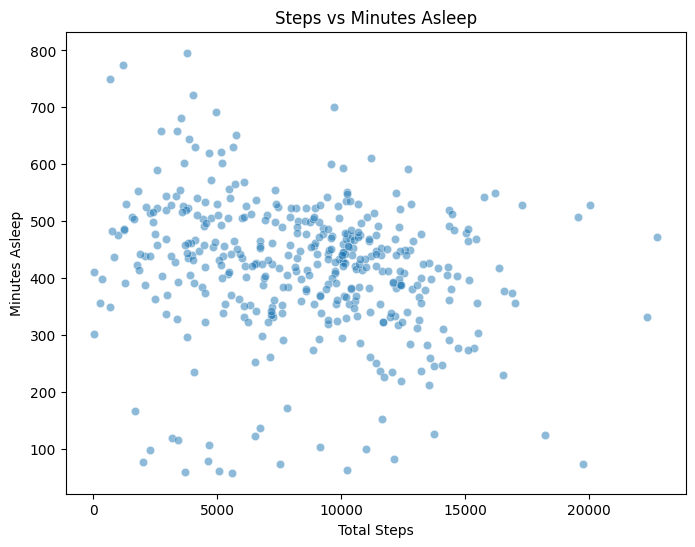

Correlation between steps and sleep: -0.19


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=daily_full, x='TotalSteps', y='TotalMinutesAsleep', alpha=0.5)
plt.title('Steps vs Minutes Asleep')
plt.xlabel('Total Steps')
plt.ylabel('Minutes Asleep')
plt.show()

correlation2 = daily_full['TotalSteps'].corr(daily_full['TotalMinutesAsleep'])
print(f"Correlation between steps and sleep: {correlation2:.2f}")

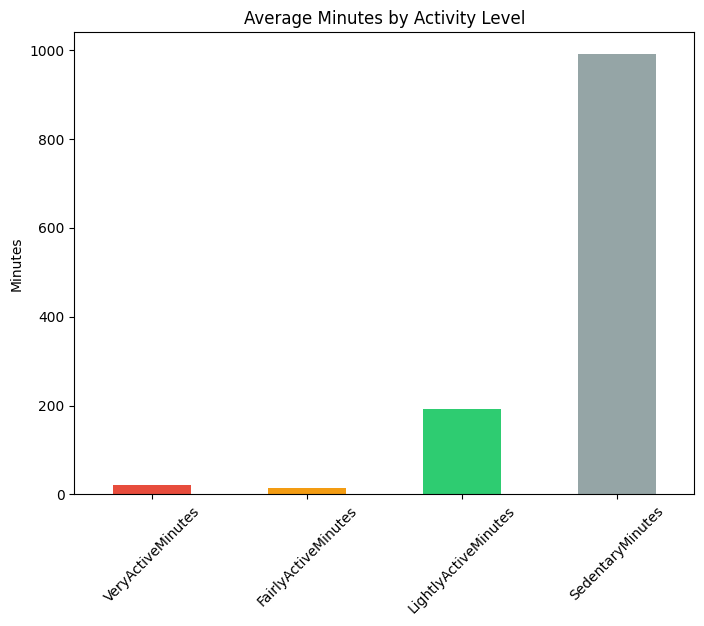

In [ ]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']
avg_minutes = daily_full[activity_cols].mean()

plt.figure(figsize=(8,6))
avg_minutes.plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71','#95a5a6'])
plt.title('Average Minutes by Activity Level')
plt.ylabel('Minutes')
plt.xticks(rotation=45)
plt.show()

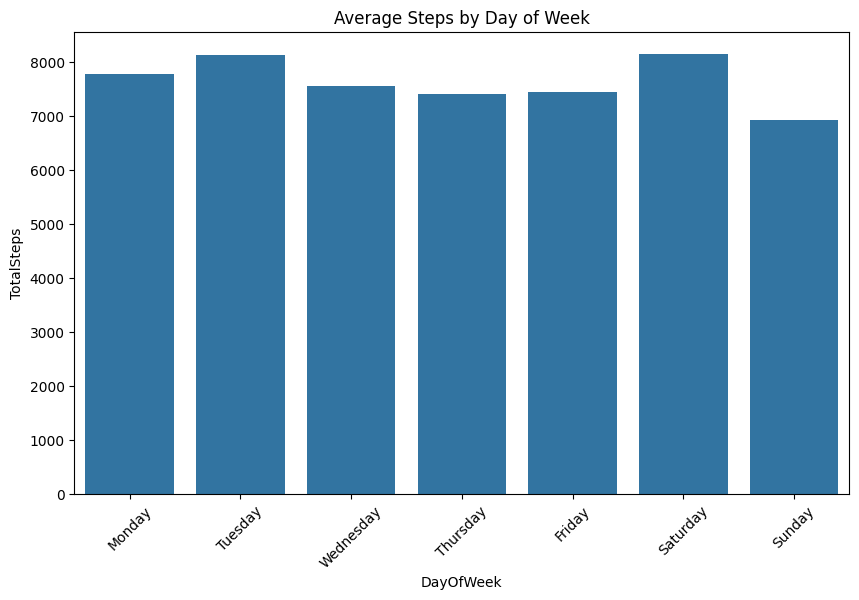

In [ ]:
daily_full['DayOfWeek'] = daily_full['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,6))
sns.barplot(data=daily_full, x='DayOfWeek', y='TotalSteps', order=day_order, errorbar=None)
plt.title('Average Steps by Day of Week')
plt.xticks(rotation=45)
plt.show()

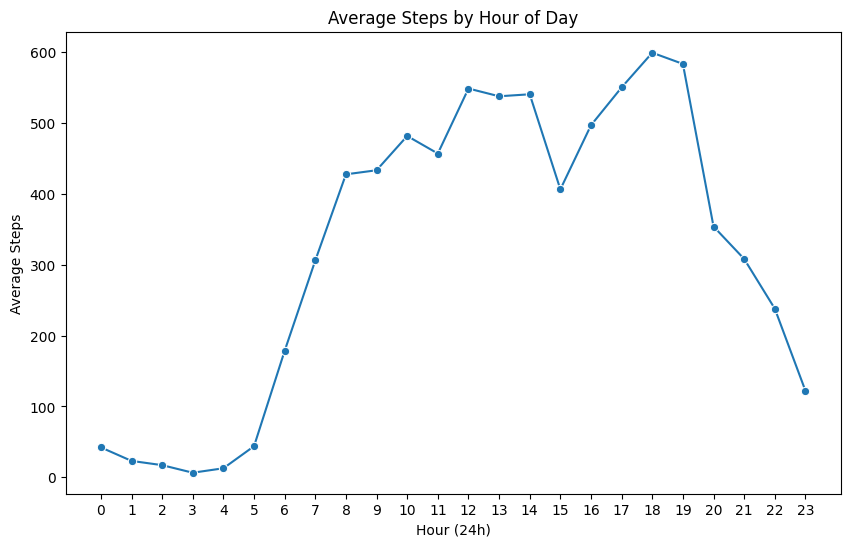

In [ ]:
hourly_merged['Hour'] = hourly_merged['ActivityHour'].dt.hour

hourly_avg = hourly_merged.groupby('Hour')['StepTotal'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=hourly_avg, x='Hour', y='StepTotal', marker='o')
plt.title('Average Steps by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Average Steps')
plt.xticks(range(0,24))
plt.show()

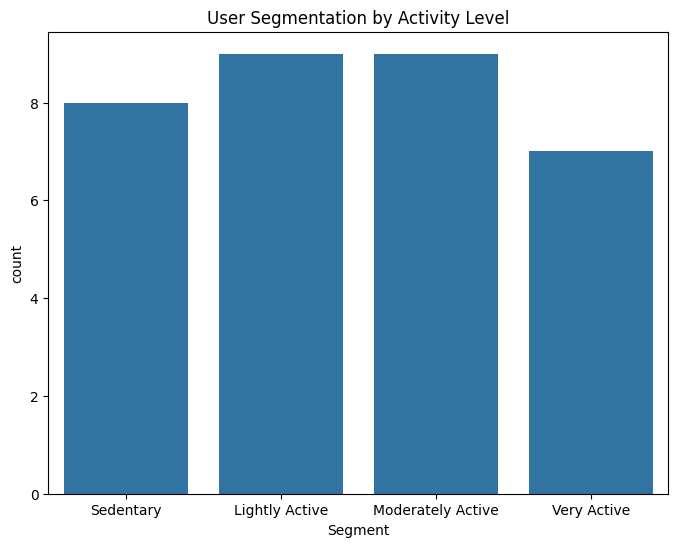

,count
Segment,
Lightly Active,9
Moderately Active,9
Sedentary,8
Very Active,7


In [ ]:
user_avg_steps = daily_full.groupby('Id')['TotalSteps'].mean().reset_index()

def classify_user(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Lightly Active'
    elif steps < 10000:
        return 'Moderately Active'
    else:
        return 'Very Active'

user_avg_steps['Segment'] = user_avg_steps['TotalSteps'].apply(classify_user)

plt.figure(figsize=(8,6))
sns.countplot(data=user_avg_steps, x='Segment', order=['Sedentary','Lightly Active','Moderately Active','Very Active'])
plt.title('User Segmentation by Activity Level')
plt.show()

user_avg_steps['Segment'].value_counts()

In [ ]:
daily_full.to_csv('/content/drive/MyDrive/fitness-project/cleaned_daily_full.csv', index=False)

In [ ]:
from google.colab import files

daily_activity.to_csv('cleaned_daily_activity.csv', index=False)
sleep.to_csv('cleaned_sleep.csv', index=False)
hourly_merged.to_csv('cleaned_hourly_merged.csv', index=False)

files.download('cleaned_daily_activity.csv')
files.download('cleaned_sleep.csv')
files.download('cleaned_hourly_merged.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>